# LSTM — Proactive CPU Demand Forecasting (Baseline Model)
**Role:** Main proposed model  
**Data:** `Final_Cleaned_1m.parquet` — 1,303 services  
**Features (X):** `total_traffic`, `avg_node_stress`, `replica_count`, `avg_response_time`  
**Target (y):** `total_cpu_demand` (separately)  
**Split:** every-4th-sample → val (ensures similar time distributions)  
**Scaling:** log1p → MinMaxScaler on both X and y  
**Metrics:** R², MAE, RMSE, MAPE → `results/all_models_results.csv`

In [25]:
import polars as pl
import joblib
import keras
import pandas as pd
import random, os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from pathlib import Path
import random
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Imports done")

Imports done


In [20]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Global seed set to {SEED}")

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH    = str(PROJECT_ROOT / 'cleanData' / 'Final_Cleaned_1m.parquet')
PLOTS_DIR    = str(PROJECT_ROOT / 'plots')
MODELS_DIR   = str(PROJECT_ROOT / 'models')
RESULTS_CSV  = str(PROJECT_ROOT / 'results' / 'all_models_results.csv')
os.makedirs(PLOTS_DIR,  exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(str(PROJECT_ROOT / 'results'), exist_ok=True)

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})

def save_result(model_name, r2, mae, rmse, mape):
    row = pd.DataFrame([{'model':model_name,'R2':round(float(r2),4),
        'MAE':round(float(mae),4),'RMSE':round(float(rmse),4),'MAPE':round(float(mape),2)}])
    if os.path.exists(RESULTS_CSV):
        ex = pd.read_csv(RESULTS_CSV)
        row = pd.concat([ex[ex['model']!=model_name], row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"  Saved \u2192 results/all_models_results.csv")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data         : {DATA_PATH}")

Global seed set to 42
Project root : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale
Data         : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\cleanData\Final_Cleaned_1m.parquet


In [2]:
print("Loading Cleaned 1-Minute Data...")

file_path = "../cleanData/Final_Cleaned_1m.parquet"
df_final_1m = pl.read_parquet(file_path)

print(f"Loaded Shape: {df_final_1m.shape}")
print(f"Columns: {df_final_1m.columns}")
print(f"Timestamp range: {df_final_1m['timestamp'].min()} to {df_final_1m['timestamp'].max()}")
print(f"Unique services: {df_final_1m['msname'].n_unique()}")
print("Null counts per column:")
print(df_final_1m.null_count())

Loading Cleaned 1-Minute Data...
Loaded Shape: (937986, 8)
Columns: ['msname', 'timestamp', 'total_cpu_demand', 'total_memory_demand', 'total_traffic', 'avg_node_stress', 'avg_response_time', 'replica_count']
Timestamp range: 0 to 43140000
Unique services: 1303
Null counts per column:
shape: (1, 8)
┌────────┬───────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ msname ┆ timestamp ┆ total_cpu_ ┆ total_memo ┆ total_traf ┆ avg_node_s ┆ avg_respon ┆ replica_co │
│ ---    ┆ ---       ┆ demand     ┆ ry_demand  ┆ fic        ┆ tress      ┆ se_time    ┆ unt        │
│ u32    ┆ u32       ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│        ┆           ┆ u32        ┆ u32        ┆ u32        ┆ u32        ┆ u32        ┆ u32        │
╞════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 0      ┆ 0         ┆ 0          ┆ 0          ┆ 0          ┆ 0          ┆ 2752       ┆ 0     

In [3]:
print("Analyzing Microservice Workload Imbalance...")

# 1. Group by microservice and sum the total traffic over the 12 hours
df_traffic = df_final_1m.group_by("msname").agg(
    pl.col("total_traffic").sum().alias("total_invocations")
).sort("total_invocations", descending=True)

# 2. Calculate the total cluster traffic
cluster_total_traffic = df_traffic["total_invocations"].sum()

# 3. Calculate cumulative traffic percentages
df_traffic = df_traffic.with_columns(
    (pl.col("total_invocations").cum_sum() / cluster_total_traffic * 100).alias("cumulative_traffic_percent")
)

# 4. Find out how many microservices make up the top 5% of the unique services
total_microservices = df_traffic.height
top_5_percent_count = int(total_microservices * 0.05)

print(f"Total Unique Microservices: {total_microservices}")
print(f"Top 5% Count: {top_5_percent_count} microservices")

# 5. See what percentage of total traffic those top 5% handle
top_5_traffic_share = df_traffic["cumulative_traffic_percent"][top_5_percent_count - 1]

print(f"The top 5% of microservices handle {top_5_traffic_share:.2f}% of all total invocations!")


Analyzing Microservice Workload Imbalance...
Total Unique Microservices: 1303
Top 5% Count: 65 microservices
The top 5% of microservices handle 62.59% of all total invocations!


In [4]:
print("Filtering to top 5% hot-spot microservices...")

service_traffic = df_final_1m.group_by("msname").agg(
    pl.col("total_traffic").sum().alias("lifetime_traffic")
).sort("lifetime_traffic", descending=True)

top_n = max(1, int(len(service_traffic) * 0.05))
top_services = service_traffic.head(top_n).select("msname")

df_hotspot = df_final_1m.join(top_services, on="msname", how="inner")

print(f"Total services:       {df_final_1m['msname'].n_unique()}")
print(f"Hot-spot services:    {df_hotspot['msname'].n_unique()}")
print(f"Rows before filter:   {df_final_1m.shape[0]:,}")
print(f"Rows after filter:    {df_hotspot.shape[0]:,}")

total_traffic   = df_final_1m['total_traffic'].sum()
hotspot_traffic = df_hotspot['total_traffic'].sum()
print(f"Traffic coverage:     {hotspot_traffic/total_traffic*100:.2f}%")

Filtering to top 5% hot-spot microservices...
Total services:       1303
Hot-spot services:    65
Rows before filter:   937,986
Rows after filter:    46,800
Traffic coverage:     62.59%


In [5]:
print("CPU Demand Statistics:")
print(df_final_1m.select("total_cpu_demand").describe())

print("\nSample rows:")
print(df_final_1m.select([
    "msname", "timestamp", "total_cpu_demand",
    "total_traffic", "avg_node_stress",
    "replica_count", "avg_response_time"
]).head(5))

CPU Demand Statistics:
shape: (9, 2)
┌────────────┬──────────────────┐
│ statistic  ┆ total_cpu_demand │
│ ---        ┆ ---              │
│ str        ┆ f64              │
╞════════════╪══════════════════╡
│ count      ┆ 937986.0         │
│ null_count ┆ 0.0              │
│ mean       ┆ 13.935048        │
│ std        ┆ 56.629109        │
│ min        ┆ 0.0              │
│ 25%        ┆ 0.659875         │
│ 50%        ┆ 2.296844         │
│ 75%        ┆ 8.586229         │
│ max        ┆ 1712.046066      │
└────────────┴──────────────────┘

Sample rows:
shape: (5, 7)
┌──────────────┬───────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ msname       ┆ timestamp ┆ total_cpu_de ┆ total_traffi ┆ avg_node_st ┆ replica_cou ┆ avg_respons │
│ ---          ┆ ---       ┆ mand         ┆ c            ┆ ress        ┆ nt          ┆ e_time      │
│ str          ┆ i64       ┆ ---          ┆ ---          ┆ ---         ┆ ---         ┆ ---         │
│              ┆     

In [6]:
print("Building sliding windows...")

WINDOW_SIZE = 5
PREDICT_STEPS = 1
features = [
    "total_traffic",       # workload signal
    "avg_node_stress",     # host interference
    "replica_count",       # service scale
    "avg_response_time"   # performance signal

]

X_raw = []
y_raw = []

for name, group in df_final_1m.sort("timestamp").group_by("msname"):
    # Fill null response times with 0
    group = group.with_columns(
        pl.col("avg_response_time").fill_null(0)
    )
    X_array = group.select(features).to_numpy()
    # y uses cpu demand separately
    y_array = group.select("total_cpu_demand").to_numpy()

    for i in range(WINDOW_SIZE, len(X_array) - PREDICT_STEPS + 1):
        X_raw.append(X_array[i-WINDOW_SIZE : i, :])
        y_raw.append(y_array[i : i+PREDICT_STEPS, 0])

X_raw = np.array(X_raw)
y_raw = np.array(y_raw).reshape(-1, PREDICT_STEPS)

print(f"X_raw Shape: {X_raw.shape}")
print(f"y_raw Shape: {y_raw.shape}")
print(f"\nFirst window (5 timesteps x 4 features):")
print(X_raw[0])   # prints first sample only
print(f"\nFirst y sequence (Next {PREDICT_STEPS} minutes of CPU cores):")
print(y_raw[0])   # prints first sample only


print(f"\ny_raw max:  {y_raw.max():.4f} cores")
print(f"y_raw mean: {y_raw.mean():.4f} cores")

Building sliding windows...
X_raw Shape: (931471, 5, 4)
y_raw Shape: (931471, 1)

First window (5 timesteps x 4 features):
[[2.20967395e+04 7.30353970e-01 3.70000000e+01 2.78586115e+01]
 [2.00481500e+04 7.28906154e-01 3.70000000e+01 8.43874861e+00]
 [2.02453833e+04 7.27888230e-01 3.70000000e+01 8.32410723e+00]
 [2.04423167e+04 7.23109172e-01 3.70000000e+01 8.06365479e+00]
 [2.06357500e+04 7.21370802e-01 3.70000000e+01 8.55123247e+00]]

First y sequence (Next 1 minutes of CPU cores):
[8.65715042]

y_raw max:  1712.0461 cores
y_raw mean: 13.9350 cores


In [7]:
print("Splitting into Train/Validation sets...")

# Instead of last 30% as val, take every 4th window as val
# This ensures both sets have similar time distributions
val_indices   = np.arange(0, len(X_raw), 4)       # every 4th sample → val
train_indices = np.setdiff1d(np.arange(len(X_raw)), val_indices)  # rest → train

X_train_raw = X_raw[train_indices]
X_val_raw   = X_raw[val_indices]
y_train_raw = y_raw[train_indices]
y_val_raw   = y_raw[val_indices]

print(f"X_train: {X_train_raw.shape} | X_val: {X_val_raw.shape}")
print(f"y_train: {y_train_raw.shape} | y_val: {y_val_raw.shape}")

# Verify distributions match
print("\nTrain y distribution:")
for p in [25, 50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(y_train_raw, p):.4f} cores")

print("\nVal y distribution:")
for p in [25, 50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(y_val_raw, p):.4f} cores")

Splitting into Train/Validation sets...
X_train: (698603, 5, 4) | X_val: (232868, 5, 4)
y_train: (698603, 1) | y_val: (232868, 1)

Train y distribution:
  p25: 0.6599 cores
  p50: 2.2965 cores
  p75: 8.5835 cores
  p90: 31.1629 cores
  p95: 58.4590 cores

Val y distribution:
  p25: 0.6596 cores
  p50: 2.2974 cores
  p75: 8.5912 cores
  p90: 31.2021 cores
  p95: 58.3865 cores


In [14]:
print("Splitting into Train/Validation sets...")

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.3,
    shuffle=False
)

print(f"X_train: {X_train_raw.shape} | X_val: {X_val_raw.shape}")
print(f"y_train: {y_train_raw.shape} | y_val: {y_val_raw.shape}")

Splitting into Train/Validation sets...
X_train: (652029, 5, 4) | X_val: (279442, 5, 4)
y_train: (652029, 1) | y_val: (279442, 1)


In [13]:
print("Scaling features...")

n_train, timesteps, n_features = X_train_raw.shape

# Scale X
X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(
    X_train_raw.reshape(-1, n_features)
).reshape(n_train, timesteps, n_features)

X_val_scaled = X_scaler.transform(
    X_val_raw.reshape(-1, n_features)
).reshape(X_val_raw.shape)

# Scale y
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_raw)
y_val_scaled   = y_scaler.transform(y_val_raw)

# # Save scalers
# joblib.dump(X_scaler, "models/v2_1m_X_scaler.pkl")
# joblib.dump(y_scaler, "models/v2_1m_y_scaler.pkl")

print(f"y scaler range: {y_scaler.data_min_[0]:.4f} to {y_scaler.data_max_[0]:.4f} cores")
print("Scalers saved to 'models/' folder")

print(f"y_train_raw shape: {y_train_raw.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")

Scaling features...
y scaler range: 0.0000 to 1712.0461 cores
Scalers saved to 'models/' folder
y_train_raw shape: (652029, 1)
y_train_scaled shape: (652029, 1)


In [ ]:
print("Clipping and Scaling...")

n_train, timesteps, n_features = X_train_raw.shape

# ── Step 1: Clip outliers ────────────────────────────────
CLIP_PERCENTILE = 99.5

# Clip y
y_clip_max    = np.percentile(y_train_raw, CLIP_PERCENTILE)
y_train_clipped = np.clip(y_train_raw, 0, y_clip_max)
y_val_clipped   = np.clip(y_val_raw,   0, y_clip_max)
print(f"y clipped at {y_clip_max:.4f} cores (p{CLIP_PERCENTILE})")

# Clip X
X_train_clipped = X_train_raw.copy()
X_val_clipped   = X_val_raw.copy()
for i in range(n_features):
    x_clip_max = np.percentile(X_train_raw[:, :, i], CLIP_PERCENTILE)
    X_train_clipped[:, :, i] = np.clip(X_train_raw[:, :, i], 0, x_clip_max)
    X_val_clipped[:, :, i]   = np.clip(X_val_raw[:, :, i],   0, x_clip_max)

# ── Step 2: Scale X ──────────────────────────────────────
X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(
    X_train_clipped.reshape(-1, n_features)
).reshape(n_train, timesteps, n_features)

X_val_scaled = X_scaler.transform(
    X_val_clipped.reshape(-1, n_features)
).reshape(X_val_clipped.shape)

# ── Step 3: Scale y ──────────────────────────────────────
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_clipped)
y_val_scaled   = y_scaler.transform(y_val_clipped)

# ── Step 4: Save scalers ─────────────────────────────────
joblib.dump(X_scaler, "models/v2_1m_X_scaler.pkl")
joblib.dump(y_scaler, "models/v2_1m_y_scaler.pkl")

# ── Step 5: Verify ───────────────────────────────────────
print(f"y_scaler max:      {y_scaler.data_max_[0]:.4f} cores")
print(f"y_train shape:     {y_train_scaled.shape}")
print(f"y_val shape:       {y_val_scaled.shape}")
print("Scalers saved!")

Clipping and Scaling...
y clipped at 1649.2828 cores (p99.5)
y_scaler max:      1649.2828 cores
y_train shape:     (32532, 1)
y_val shape:       (13943, 1)
Scalers saved!


In [8]:
print("Scaling with Log Transform...")

n_train, timesteps, n_features = X_train_raw.shape

# ── Step 1: Log transform y ──────────────────────────────
y_train_log = np.log1p(y_train_raw)
y_val_log   = np.log1p(y_val_raw)

print(f"y_train_raw range:  {y_train_raw.min():.4f} to {y_train_raw.max():.4f} cores")
print(f"y_train_log range:  {y_train_log.min():.4f} to {y_train_log.max():.4f}")

# ── Step 2: Log transform X ──────────────────────────────
X_train_log = np.log1p(X_train_raw)
X_val_log   = np.log1p(X_val_raw)

print(f"\nX_train_raw range:  {X_train_raw.min():.4f} to {X_train_raw.max():.4f}")
print(f"X_train_log range:  {X_train_log.min():.4f} to {X_train_log.max():.4f}")

# ── Step 3: Scale X ──────────────────────────────────────
X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(
    X_train_log.reshape(-1, n_features)
).reshape(n_train, timesteps, n_features)

X_val_scaled = X_scaler.transform(
    X_val_log.reshape(-1, n_features)
).reshape(X_val_log.shape)

# ── Step 4: Scale log-transformed y ──────────────────────
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_log)
y_val_scaled   = y_scaler.transform(y_val_log)

# ── Step 5: Save scalers ──────────────────────────────────
joblib.dump(X_scaler, "models/v2_1m_X_scaler.pkl")
joblib.dump(y_scaler, "models/v2_1m_y_scaler.pkl")

# ── Step 6: Verify shapes match ───────────────────────────
print(f"\nX_train_scaled: {X_train_scaled.shape}")
print(f"y_train_scaled: {y_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"y_val_scaled:   {y_val_scaled.shape}")
print(f"\ny_scaler range: {y_scaler.data_min_[0]:.4f} to {y_scaler.data_max_[0]:.4f} (log scale)")
print("Scalers saved!")

Scaling with Log Transform...
y_train_raw range:  0.0000 to 1712.0461 cores
y_train_log range:  0.0000 to 7.4460

X_train_raw range:  0.0000 to 247573664.3840
X_train_log range:  0.0000 to 19.3272

X_train_scaled: (698603, 5, 4)
y_train_scaled: (698603, 1)
X_val_scaled:   (232868, 5, 4)
y_val_scaled:   (232868, 1)

y_scaler range: 0.0000 to 7.4460 (log scale)
Scalers saved!


In [9]:
feature_names = ["total_traffic", "avg_node_stress", "replica_count", "avg_response_time"]

print("X_train_raw ranges per feature:")
for i, name in enumerate(feature_names):
    fmin = X_train_raw[:, :, i].min()
    fmax = X_train_raw[:, :, i].max()
    lmin = np.log1p(X_train_raw[:, :, i]).min()
    lmax = np.log1p(X_train_raw[:, :, i]).max()
    print(f"  {name}:")
    print(f"    raw:  {fmin:.4f} to {fmax:.4f}")
    print(f"    log:  {lmin:.4f} to {lmax:.4f}")

X_train_raw ranges per feature:
  total_traffic:
    raw:  0.0000 to 247573664.3840
    log:  0.0000 to 19.3272
  avg_node_stress:
    raw:  0.0037 to 0.8871
    log:  0.0037 to 0.6351
  replica_count:
    raw:  1.0000 to 2717.0000
    log:  0.6931 to 7.9077
  avg_response_time:
    raw:  0.0000 to 459909.3159
    log:  0.0000 to 13.0388


In [10]:
print("Building LSTM Model...")

model = Sequential()
model.add(keras.Input(shape=(timesteps, n_features)))
model.add(LSTM(units=50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=PREDICT_STEPS))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse'
)
print(model.summary())

Building LSTM Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
print("Starting Training...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "models/best_lstm_model.keras",
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=128,
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=[early_stop, checkpoint]
)

print("\nTraining Complete!")

Starting Training...
Epoch 1/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0035 - val_loss: 0.0018
Epoch 2/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 3/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 4/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 5/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 6/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 7/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 8/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 9/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 10/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 11/100
5458/5458 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0018 - val_

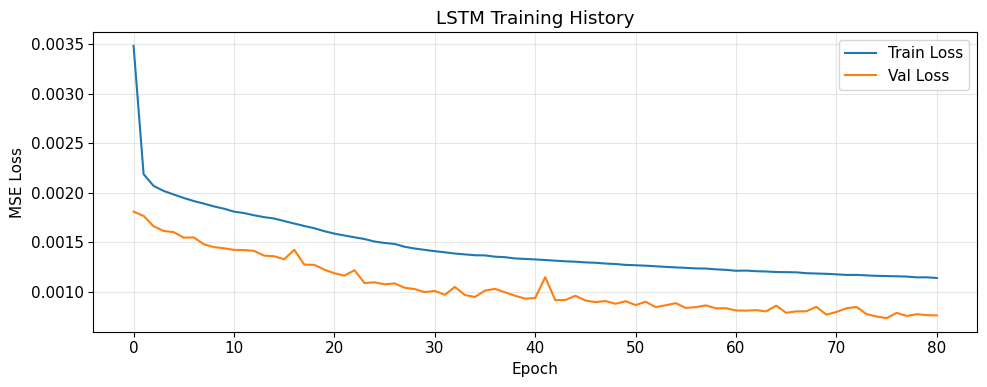

Saved to 'models/training_history.png'


In [30]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training History')
plt.legend()
plt.tight_layout()
plt.savefig("models/training_history.png", dpi=150)
plt.show()
print("Saved to 'models/training_history.png'")

In [ ]:
model.save("models/best_lstm_model.keras")
print("\nModel saved to 'models/best_lstm_model.keras'")


✅ Model saved to 'models/best_lstm_model.keras'


In [27]:
print("Evaluating on full validation set...")

pred_scaled = model.predict(X_val_scaled)
pred_log    = y_scaler.inverse_transform(pred_scaled)
pred_actual = np.expm1(pred_log)

true_log    = y_scaler.inverse_transform(y_val_scaled)
true_actual = np.expm1(true_log)

mae  = mean_absolute_error(true_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
r2   = r2_score(true_actual, pred_actual)
mape = np.mean(np.abs((true_actual - pred_actual) / (true_actual + 1e-8))) * 100


print("=" * 40)
print("MODEL EVALUATION REPORT")
print("=" * 40)
print(f"MAE  (Mean Absolute Error):     {mae:.4f} cores")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f} cores")
print(f"R²   (Explained Variance):      {r2:.4f}")
print(f'MAPE (Mean Absolute % Error):   {mape:.2f}%')

print(f"Evaluated on:                   {len(true_actual):,} samples")
print("=" * 40)
save_result('LSTM', r2, mae, rmse, mape )

Evaluating on full validation set...
7278/7278 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
MODEL EVALUATION REPORT
MAE  (Mean Absolute Error):     2.5676 cores
RMSE (Root Mean Squared Error): 15.4606 cores
R²   (Explained Variance):      0.9252
MAPE (Mean Absolute % Error):   853.62%
Evaluated on:                   232,868 samples
  Saved → results/all_models_results.csv


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


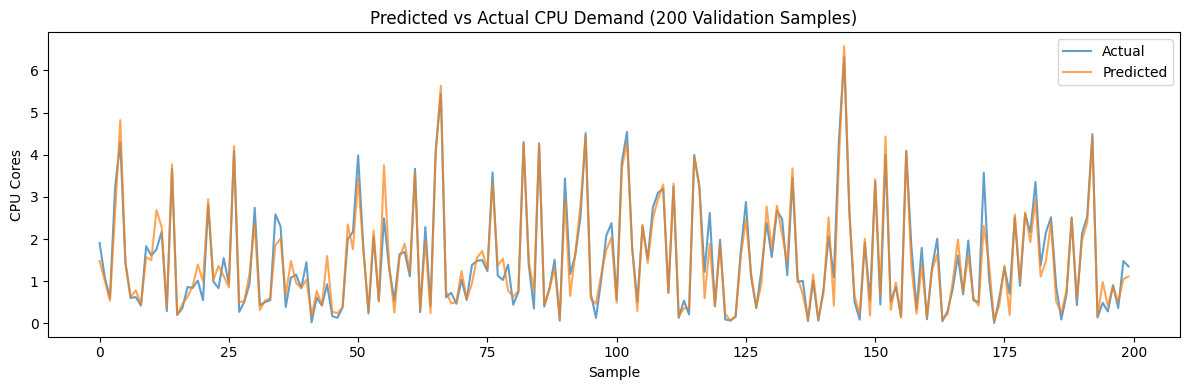

Saved to 'models/prediction_plot.png'


In [20]:
n_check = 200
indices = np.linspace(0, len(X_val_scaled)-1, n_check, dtype=int)

pred_plot = y_scaler.inverse_transform(
    model.predict(X_val_scaled[indices])
)
true_plot = y_scaler.inverse_transform(y_val_scaled[indices])

plt.figure(figsize=(12, 4))
plt.plot(true_plot, label='Actual',    alpha=0.7)
plt.plot(pred_plot, label='Predicted', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('CPU Cores')
plt.title('Predicted vs Actual CPU Demand (200 Validation Samples)')
plt.legend()
plt.tight_layout()
plt.savefig("models/prediction_plot.png", dpi=150)
plt.show()
print("Saved to 'models/prediction_plot.png'")

In [13]:
print("Hot-spot CPU statistics:")
print(df_hotspot.select("total_cpu_demand").describe())

print("\ny_scaler range:")
print(f"  Min: {y_scaler.data_min_[0]:.4f}")
print(f"  Max: {y_scaler.data_max_[0]:.4f}")

print("\nSample predictions vs actual:")
print(f"{'Predicted':>12}  {'Actual':>12}  {'Difference':>12}")
print("-" * 40)
for pred, actual in zip(pred_actual[:10], true_actual[:10]):
    diff = abs(pred[0] - actual[0])
    print(f"{pred[0]:>12.4f}  {actual[0]:>12.4f}  {diff:>12.4f}")

Hot-spot CPU statistics:
shape: (9, 2)
┌────────────┬──────────────────┐
│ statistic  ┆ total_cpu_demand │
│ ---        ┆ ---              │
│ str        ┆ f64              │
╞════════════╪══════════════════╡
│ count      ┆ 46800.0          │
│ null_count ┆ 0.0              │
│ mean       ┆ 137.857987       │
│ std        ┆ 209.404404       │
│ min        ┆ 8.196194         │
│ 25%        ┆ 48.464577        │
│ 50%        ┆ 88.035319        │
│ 75%        ┆ 155.022538       │
│ max        ┆ 1712.046066      │
└────────────┴──────────────────┘

y_scaler range:
  Min: 0.0000
  Max: 7.4460

Sample predictions vs actual:
   Predicted        Actual    Difference
----------------------------------------


NameError: name 'pred_actual' is not defined

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


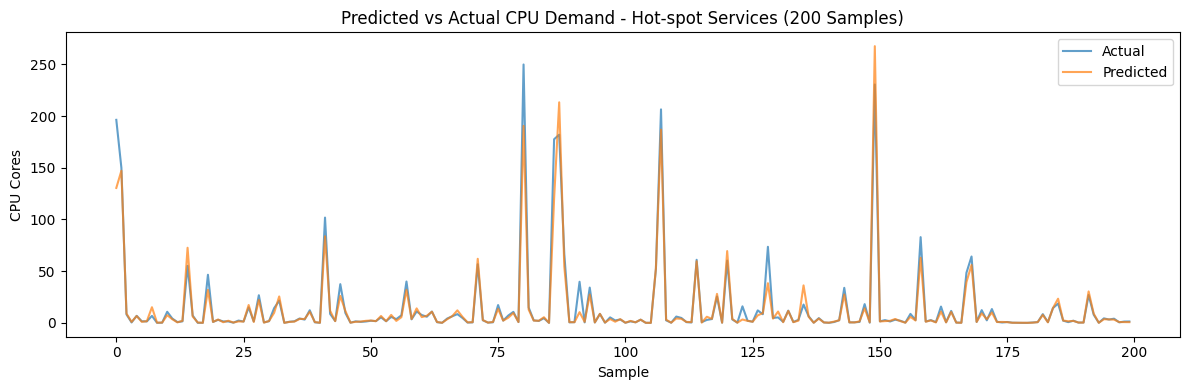

In [ ]:
n_check = 200
indices = np.linspace(0, len(X_val_scaled)-1, n_check, dtype=int)

pred_plot_scaled = model.predict(X_val_scaled[indices])
pred_plot = np.expm1(y_scaler.inverse_transform(pred_plot_scaled))
true_plot = np.expm1(y_scaler.inverse_transform(y_val_scaled[indices]))

plt.figure(figsize=(12, 4))
plt.plot(true_plot, label='Actual',    alpha=0.7)
plt.plot(pred_plot, label='Predicted', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('CPU Cores')
plt.title('Predicted vs Actual CPU Demand - Hot-spot Services (200 Samples)')
plt.legend()
plt.tight_layout()
plt.savefig("models/prediction_plot.png", dpi=150)
plt.show()